# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## Sistemas Jerárquicos de N-cuerpos

In [1]:
!pip install -Uq pymcel celluloid


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
G = 1 # Sistema de unidades canónicas

## Sistema jerarquico

En esta actividad crearemos un sistema jerárquico de tres cuerpos: 2 estrellas y un planeta que gira alrededor de una de las estrellas.

Llamaremos al sistema Zul y a las componenes: Zul Aa (estrella primaria), Zul Ab (planeta) y Zul B (estrella secundaria)

El árbol de relaciones entre estas componentes es:

```text
Zul (sistema total)
├── A (subsistema interno)
│   ├── Aa (estrella primaria)
│   └── Ab (planeta)
└── B (estrella secundaria)
```

Masas:

In [4]:
m_Zul_Aa = 1.0
m_Zul_Ab = 0.01
m_Zul_B = 1.0

Para inicializar las condiciones iniciales del sistema jerárquico lo mejor es comenzar con las coordenadas de Jacobi de los dos subsistemas:

In [5]:
# Sistema A: Aa + Ab
m_Zul_A = m_Zul_Aa + m_Zul_Ab
r_Zul_A = np.array([0.1, 0.0, 0.0])
v_Zul_A = np.array([0.0, 4.0, 0.0])

# Sistema A-B
r_Zul_AB = np.array([1.0, 0.0, 0.0])
v_Zul_AB = np.array([0.0, 3.0, 0.0])

Ahora necesitamos descender por el arbol del sistema. Para ello se debe fija primero que todo las propiedades de la raíz del árbol jerarquico: el centro de masa de todo el sistema:

In [6]:
RCM_Zul_AB = np.array([0.0, 0.0, 0.0])
VCM_Zul_AB = np.array([0.0, 0.0, 0.0])

Comenzamos descendiendo por la primera ramificación del árbol. En esta ramificación la partícula 1 sera el sistema A y la partícula 2 será la estrella B.

In [12]:
# Sistema A es la partícula 1:
RCM_Zul_A = RCM_Zul_AB + m_Zul_B / (m_Zul_A + m_Zul_B) * r_Zul_AB
VCM_Zul_A = VCM_Zul_AB + m_Zul_B / (m_Zul_A + m_Zul_B) * v_Zul_AB

# Sistema B es la partícula 2:
r_Zul_B = RCM_Zul_AB - m_Zul_A / (m_Zul_A + m_Zul_B) * r_Zul_AB
v_Zul_B = VCM_Zul_AB - m_Zul_A / (m_Zul_A + m_Zul_B) * v_Zul_AB

RCM_Zul_A, VCM_Zul_A, r_Zul_B, v_Zul_B

(array([0.49751244, 0.        , 0.        ]),
 array([0.        , 1.49253731, 0.        ]),
 array([-0.50248756,  0.        ,  0.        ]),
 array([ 0.        , -1.50746269,  0.        ]))

Descendemos ahora por la rama del sistema A: la partícula 1 será ahora la estrella Aa y la partícula 2 será ahora el planeta Ab:

In [8]:
# Estrell Aa es la partícula 1:
r_Zul_Aa = RCM_Zul_A + m_Zul_Ab / m_Zul_A * r_Zul_A
v_Zul_Aa = VCM_Zul_A + m_Zul_Ab / m_Zul_A * v_Zul_A

# Planeta Ab es la partícula 2:
r_Zul_Ab = RCM_Zul_A - m_Zul_Aa / m_Zul_A * r_Zul_A
v_Zul_Ab = VCM_Zul_A - m_Zul_Aa / m_Zul_A * v_Zul_A

r_Zul_Aa, v_Zul_Aa, r_Zul_Ab, v_Zul_Ab

(array([0.49850254, 0.        , 0.        ]),
 array([0.        , 1.53214127, 0.        ]),
 array([0.39850254, 0.        , 0.        ]),
 array([ 0.        , -2.46785873,  0.        ]))

## Simulación del sistema

Teniendo las posiciones finales podemos usar ncuerpos_solución para simular la evolución del sistema

In [9]:
sistema = [
    dict(m = m_Zul_Aa, r = r_Zul_Aa, v = r_Zul_Aa),
    dict(m = m_Zul_Ab, r = r_Zul_Ab, v = v_Zul_Ab),
    dict(m = m_Zul_B, r = r_Zul_B, v = v_Zul_B)
]
ts = np.linspace(0, 10, 1000)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

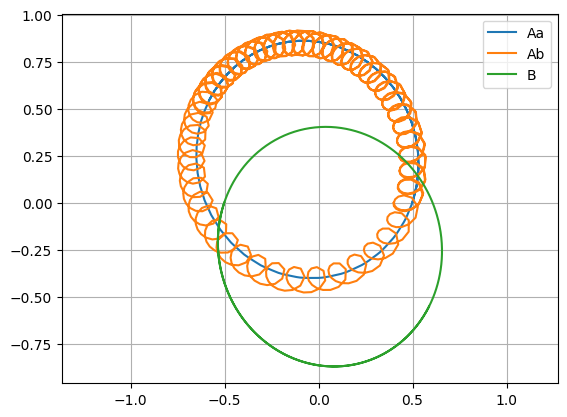

In [10]:
plt.plot(rps[0, :, 0], rps[0, :, 1], '-', label='Aa')
plt.plot(rps[1, :, 0], rps[1, :, 1], '-', label='Ab')
plt.plot(rps[2, :, 0], rps[2, :, 1], '-', label='B')
plt.legend()
plt.axis('equal')
plt.grid()

Vamos ahora a animarlo con celluloid:

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
camera = Camera(fig)

# Fondo del grafico (una sola vez).
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.3)

# Menos cuadros => render mas rapido.
step = 10

for i in range(0, len(ts), step):
    ax.plot(rps[0, :, 0], rps[0, :, 1], 'k-', lw=1, alpha=0.25, label='Aa')
    ax.plot(rps[1, :, 0], rps[1, :, 1], 'k-', lw=1, alpha=0.25, label='Ab')
    ax.plot(rps[2, :, 0], rps[2, :, 1], 'k-', lw=1, alpha=0.25, label='B')
    ax.plot(rps[0, i, 0], rps[0, i, 1], 'ro', ms=7)
    ax.plot(rps[1, i, 0], rps[1, i, 1], 'bo', ms=5)
    ax.plot(rps[2, i, 0], rps[2, i, 1], 'ko', ms=6)
    camera.snap()

anim = camera.animate(interval=60, blit=False)
plt.close(fig)

from IPython.display import HTML
HTML(anim.to_jshtml())

## Ejercicio

Con las siguientes masas y condiciones iniciales:

- Masas: s = 1, e = 0.5, L = 0.001, p = 0.01.

- Condiciones iniciales: a continuación se proveen datos del vector y velocidad relativa para cada subsistema:

   - Sistema p-L: $\vec r :(0.03,0,0), \vec v : (0,0.4,0.1)$

   - Sistema e-pL (baricentro de p y L): $\vec r :(0,0.4,0), \vec v : (0.9,0,0.2)$
     
  - Sistema s-epL (baricentro e y pL): $\vec r :(2,3,0), \vec v : (-0.2,0.7,0)$